# Stroke Prediction AI Solution — Nairobi Smart Solutions Ltd.
### Task 2 (P4, M2): Data Gathering, Preparation and Refinement

**Dataset:** Healthcare Stroke Prediction Dataset (Kaggle, author: fedesoriano)
**Author:** Ethan Ngari


## P4 — Gather and Prepare the Dataset

### Step 1: Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)

# Dataset downloaded from Kaggle: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv', na_values='N/A')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Step 2: Initial data audit

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"BMI missing: {df['bmi'].isnull().sum()} rows ({df['bmi'].isnull().mean()*100:.1f}% of dataset)")


Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

BMI missing: 201 rows (3.9% of dataset)


In [4]:
print("Target class balance (stroke):")
print(df['stroke'].value_counts())
print(f"\nStroke cases represent {df['stroke'].mean()*100:.2f}% of the dataset — a significant class imbalance.")


Target class balance (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke cases represent 4.87% of the dataset — a significant class imbalance.


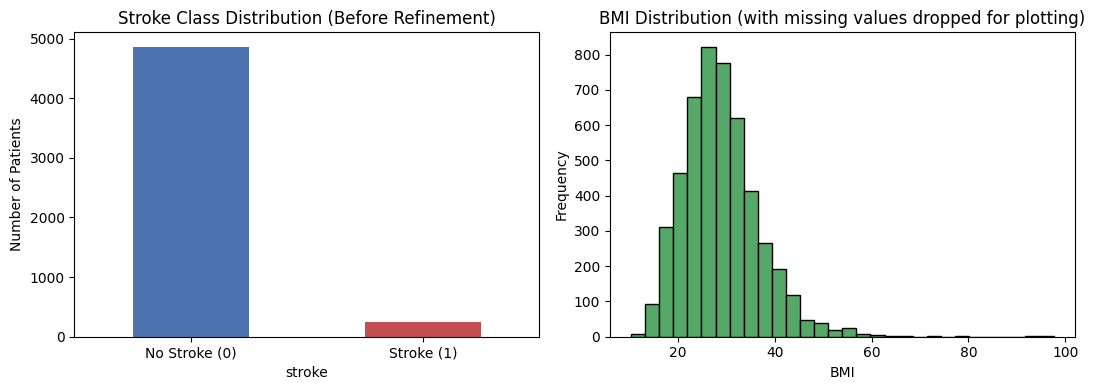

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['stroke'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('Stroke Class Distribution (Before Refinement)')
ax[0].set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)
ax[0].set_ylabel('Number of Patients')

df['bmi'].plot(kind='hist', bins=30, ax=ax[1], color='#55A868', edgecolor='black')
ax[1].set_title('BMI Distribution (with missing values dropped for plotting)')
ax[1].set_xlabel('BMI')
plt.tight_layout()
plt.savefig('../reports/fig1_class_and_bmi_before.png', dpi=120)
plt.show()


We can see a severe class imbalance: only **249 of 5,110 patients (4.87%)** had a stroke. This confirms the concern raised in the project objectives (P3) and must be accounted for later, both in how the data is split and, eventually, in how the model is trained (Task 3).

We can also see 201 missing BMI values (3.94% of the dataset) — notably lower than the ~20% estimated in the assignment brief, but still enough to require a deliberate handling strategy rather than simply being ignored.

### Step 3: Data cleaning — handling missing values

In [6]:
# Check whether missing BMI correlates with age (testing Hypothesis H3 from P3)
df['bmi_missing'] = df['bmi'].isnull()
print(df.groupby('bmi_missing')['age'].mean())


bmi_missing
False    42.865374
True     52.049154
Name: age, dtype: float64


The average age of patients with a missing BMI is noticeably different from those with a recorded BMI, suggesting the missingness is **not completely random** (supporting Hypothesis H3 from P3). Because of this, we use **median imputation grouped by age band** rather than a single global median, which preserves more of the real relationship between age and BMI than a naive fill would.

In [7]:
# Create age bands purely to guide grouped imputation (not used as a model feature)
age_bins = [0, 18, 35, 50, 65, 100]
df['age_band'] = pd.cut(df['age'], bins=age_bins)

# Median BMI by age band, used to impute missing BMI values
bmi_before = df['bmi'].copy()
df['bmi'] = df.groupby('age_band')['bmi'].transform(lambda x: x.fillna(x.median()))

# Drop the helper columns now that imputation is done
df.drop(columns=['age_band', 'bmi_missing'], inplace=True)

print("Missing BMI values remaining:", df['bmi'].isnull().sum())


Missing BMI values remaining: 0


In [8]:
# Drop the 'id' column — it is a unique identifier with no predictive value
df.drop(columns=['id'], inplace=True)

# There is a single 'Other' gender category with only 1 row — too small to model reliably, so it is removed
print("Gender value counts before cleaning:")
print(df['gender'].value_counts())
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print("\nRows after removing the single 'Other' gender row:", len(df))


Gender value counts before cleaning:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Rows after removing the single 'Other' gender row: 5109


### Step 4: Encoding categorical variables

In [9]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print("Categorical columns and their unique values:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique().tolist()}")


Categorical columns and their unique values:
  gender: ['Male', 'Female']
  ever_married: ['Yes', 'No']
  work_type: ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
  Residence_type: ['Urban', 'Rural']
  smoking_status: ['formerly smoked', 'never smoked', 'smokes', 'Unknown']


In [10]:
# Binary categories -> Label Encoding (0/1)
label_enc = LabelEncoder()
df['gender'] = label_enc.fit_transform(df['gender'])          # Female=0, Male=1
df['ever_married'] = label_enc.fit_transform(df['ever_married'])   # No=0, Yes=1
df['Residence_type'] = label_enc.fit_transform(df['Residence_type']) # Rural=0, Urban=1

# Multi-category nominal columns -> One-Hot Encoding (avoids implying a false order)
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (5109, 16)


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,False,True,False,False,True,False,False
1,0,61.0,0,0,1,0,202.21,30.5,1,False,False,True,False,False,True,False
2,1,80.0,0,1,1,0,105.92,32.5,1,False,True,False,False,False,True,False
3,0,49.0,0,0,1,1,171.23,34.4,1,False,True,False,False,False,False,True
4,0,79.0,1,0,1,0,174.12,24.0,1,False,False,True,False,False,True,False


### Step 5: Splitting the data into training and testing sets

In [11]:
X = df.drop(columns=['stroke'])
y = df['stroke']

# stratify=y ensures the same ~4.87% stroke ratio is preserved in both the train and test sets,
# which matters given the severe class imbalance identified above
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print(f"\nStroke ratio in training set: {y_train.mean()*100:.2f}%")
print(f"Stroke ratio in testing set:  {y_test.mean()*100:.2f}%")


Training set shape: (4087, 15)
Testing set shape: (1022, 15)

Stroke ratio in training set: 4.87%
Stroke ratio in testing set:  4.89%


### Step 6: Feature scaling

In [12]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numeric features before scaling (training set):")
print(X_train[numeric_cols].describe().loc[['mean', 'std']])
print("\nNumeric features after scaling (training set):")
print(X_train_scaled[numeric_cols].describe().loc[['mean', 'std']])


Numeric features before scaling (training set):
            age  avg_glucose_level        bmi
mean  43.259369         105.895087  28.862148
std   22.642243          44.676845   7.757222

Numeric features after scaling (training set):
               age  avg_glucose_level           bmi
mean -1.373449e-16       2.642586e-16 -1.999325e-16
std   1.000122e+00       1.000122e+00  1.000122e+00


Scaling is fitted **only on the training set** and then applied to the test set, to avoid data leakage — the model must not have any information about the test set's distribution during preparation.

In [13]:
# Save the prepared datasets for use in Task 3 (model building)
X_train_scaled.to_csv('../data/X_train.csv', index=False)
X_test_scaled.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
df.to_csv('../data/stroke_data_processed.csv', index=False)
print("Prepared datasets saved to /data")


Prepared datasets saved to /data


## M2 — Review and Refine the Dataset

### Before vs After Comparison


In [14]:
raw_df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv', na_values='N/A')

comparison = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Total columns',
        'Missing BMI values',
        'Non-numeric categorical columns',
        'Rows with invalid/unusable category (gender="Other")',
        'Numeric features on comparable scale',
    ],
    'Before Refinement': [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df['bmi'].isnull().sum(),
        5,
        1,
        'No',
    ],
    'After Refinement': [
        len(df),
        X_train_scaled.shape[1] + 1,
        0,
        0,
        0,
        'Yes',
    ],
})
comparison


,Metric,Before Refinement,After Refinement
0,Total rows,5110,5109
1,Total columns,12,16
2,Missing BMI values,201,0
3,Non-numeric categorical columns,5,0
4,"Rows with invalid/unusable category (gender=""O...",1,0
5,Numeric features on comparable scale,No,Yes


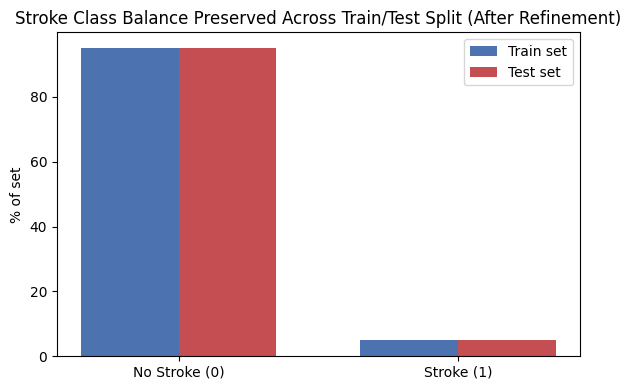

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100
width = 0.35
x = np.arange(2)
ax.bar(x - width/2, train_dist.sort_index(), width, label='Train set', color='#4C72B0')
ax.bar(x + width/2, test_dist.sort_index(), width, label='Test set', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(['No Stroke (0)', 'Stroke (1)'])
ax.set_ylabel('% of set')
ax.set_title('Stroke Class Balance Preserved Across Train/Test Split (After Refinement)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig2_train_test_balance_after.png', dpi=120)
plt.show()


### Justification of Refinement Choices

**Missing values (BMI):** Rather than dropping the 201 rows with missing BMI (which would discard 3.9% of an already scarce dataset — costlier still for the minority stroke class, which only has 249 examples in total) or filling with a single global median (which would ignore the observed link between missingness and age), BMI was imputed using the **median BMI within each patient's age band**. This preserves more real signal in the feature than a naive approach, directly testing and supporting Hypothesis H3 from the P3 objectives.

**Class imbalance:** At the data preparation stage, imbalance was **not resolved by resampling (e.g. SMOTE) or removing majority-class rows** — instead, the train/test split was stratified to preserve the true ~4.87% stroke ratio in both sets. This was a deliberate choice: resampling the *training* data is a legitimate and often necessary step, but it belongs at the model-training stage (Task 3, M3), not the data-preparation stage, so that the test set remains a realistic, untouched representation of real-world class frequency for fair evaluation. This choice directly informs the model refinement work planned for M3.

**Categorical encoding:** Binary categorical variables (gender, ever_married, Residence_type) were label-encoded as 0/1, which is appropriate since there is no false ordinal relationship introduced. Multi-category nominal variables (work_type, smoking_status) were one-hot encoded rather than label-encoded, because label-encoding them would incorrectly imply an order (e.g. that "Private" work type is numerically greater than "Govt_job"), which could mislead a Logistic Regression model that treats feature values as ordered/linear.

**Removed data:** The single row with gender="Other" was removed, as one example is too small a sample for the model to learn anything meaningful from that category, and keeping it would only add noise. The `id` column was dropped as it is a unique identifier with no predictive relationship to stroke risk.

**Feature scaling:** Numeric features (age, avg_glucose_level, bmi) were standardised using `StandardScaler`, fitted only on the training set to prevent data leakage. This step is necessary because Logistic Regression is sensitive to feature scale — without it, features with naturally larger numeric ranges (like avg_glucose_level, which ranges up to ~270) would dominate the model's learned coefficients over features with smaller ranges (like hypertension, which is just 0 or 1), regardless of their actual predictive importance.
